# Import Necessary Packges

In [1]:
from ase.io import read
from ase.visualize.plot import plot_atoms
from pylab import *
from prettytable import PrettyTable
import warnings
warnings.filterwarnings("ignore")

# Custom Define Functions

In [2]:
def cumulative_cond_cal(observables, kappa_tensor, prefactor=1/3):

    """Compute cumulative conductivity based on either frequency or mean-free path

       input:
       observables: (ndarray) either phonon frequency or mean-free path
       cond_tensor: (ndarray) conductivity tensor
       prefactor: (float) prefactor to average kappa tensor, 1/3 for bulk material

       output:
       observables: (ndarray) sorted phonon frequency or mean-free path
       kappa_cond (ndarray) cumulative conductivity

    """

    # Sum over kappa by directions
    kappa = np.einsum('maa->m', prefactor * kappa_tensor)

    # Sort observables
    observables_argsort_indices = np.argsort(observables)
    cumulative_kappa = np.cumsum(kappa[observables_argsort_indices])
    return observables[observables_argsort_indices], cumulative_kappa



def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

# Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

# Plot Phonon Spectra (Dispersion) and Density of State (DOS)

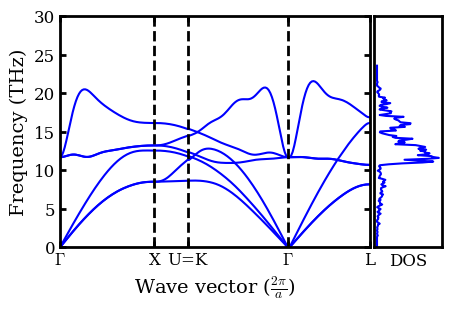

In [4]:
data_folder = './kaldo_runs_without_NAC/'

# Derive symbols for high symmetry directions in Brillouin zone
dispersion = np.loadtxt(data_folder  + 'plots/15_15_15/dispersion')
point_names = np.loadtxt(data_folder  + 'plots/15_15_15/point_names', dtype=str)

point_names_list = []
for point_name in point_names:
    if point_name == 'G':
        point_name = r'$\Gamma$'
    elif point_name == 'U':
        point_name = 'U=K'
    point_names_list.append(point_name)

# Load in the "tick-mark" values for these symbols
q = np.loadtxt(data_folder  + 'plots/15_15_15/q')
Q = np.loadtxt(data_folder  + 'plots/15_15_15/Q_val')

# Load in grid and dos individually
dos_MgO = np.load(data_folder + 'plots/15_15_15/dos.npy')

# Plot dispersion
fig = figure(figsize=(4,3))
set_fig_properties([gca()])
plot(q[0], dispersion[0, 0], 'b-', ms=1)
plot(q, dispersion, 'b-', ms=1)
for i in range(1, 4):
    axvline(x=Q[i], ymin=0, ymax=2, ls='--',  lw=2, c="k")
ylabel('Frequency (THz)', fontsize=14)
xlabel(r'Wave vector ($\frac{2\pi}{a}$)', fontsize=14)
gca().set_yticks(np.arange(0, 35, 5))
xticks(Q, point_names_list)
ylim([0, 30])
xlim([Q[0], Q[4]])
dosax = fig.add_axes([0.91, .11, .17, .77])
set_fig_properties([gca()])

# Plot per projection
for d in np.expand_dims(dos_MgO[1],0):
    dosax.plot(d, dos_MgO[0],c='b')
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS")
ylim([0, 30])
show()

# Plot Heat Capacity, Group Velocities and Phase Space

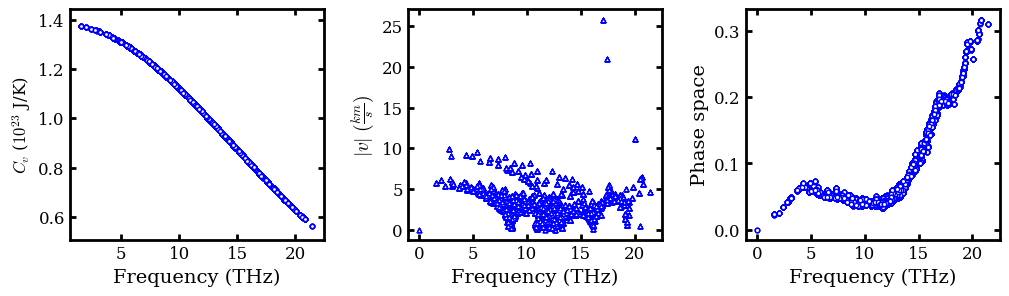

In [5]:
# Load in group velocity, heat_capacity (cv) and frequency data
frequency =  np.load(
    data_folder + 'ALD/15_15_15/frequency.npy',
    allow_pickle=True)

cv =  np.load(
    data_folder + 'ALD/15_15_15/300/quantum/heat_capacity.npy',
    allow_pickle=True)


group_velocity = np.load(
    data_folder + 'ALD/15_15_15/velocity.npy')

phase_space = np.load(data_folder +
 'ALD/15_15_15/300/quantum/_ps_and_gamma.npy',
                      allow_pickle=True)[:,0]

# Compute norm of group velocity
# Convert the unit from angstrom / picosecond to kilometer/ second
group_velcotiy_norm = np.linalg.norm(
    group_velocity.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C')[3:], 1e23*cv.flatten(order='C')[3:], 
        facecolor='w', edgecolor='b', s=10, marker='8')
ylabel (r"$C_{v}$ ($10^{23}$ J/K)")
xlabel('Frequency (THz)', fontsize=14)
ylim(0.9*1e23*cv.flatten(order='C')[3:].min(), 1.05*1e23*cv.flatten(order='C')[3:].max())

subplot(1 ,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        group_velcotiy_norm, facecolor='w', edgecolor='b', s=10, marker='^')
xlabel('Frequency (THz)', fontsize=14)
ylabel(r'$|v| \ (\frac{km}{s})$', fontsize=14)

subplot(1 ,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        phase_space, facecolor='w', edgecolor='b', s=10, marker='o')
xlabel('Frequency (THz)', fontsize=14)
ylabel('Phase space', fontsize=14)
subplots_adjust(wspace=0.33)
show()

 # Plot Phonon Life Time ($\tau$), Scattering Rate ($\Gamma$) and Mean Free Path ($\lambda$)
- Note that  $\Gamma$ and $\tau$ are computed only with the relaxation time approximation (RTA).

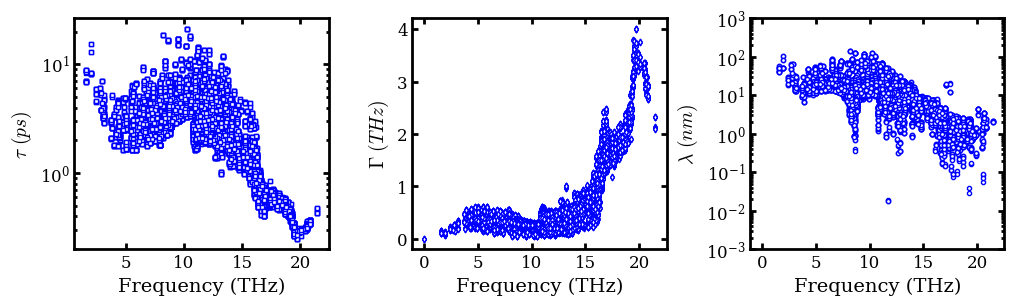

In [6]:
# Load in scattering rate
scattering_rate = np.load(
    data_folder +
    'ALD/15_15_15/300/quantum/bandwidth.npy', allow_pickle=True)

# Derive lifetime, which is inverse of scattering rate
life_time = scattering_rate ** (-1)

# Denote lists to intake mean free path in each direction
mean_free_path = []
for i in range(3):
    mean_free_path.append(np.loadtxt(
    data_folder +
    'ALD/15_15_15/inverse/300/quantum/mean_free_path_' +
    str(i) + '.dat'))

# Convert list to numpy array and compute norm for mean free path
# Convert the unit from angstrom  to nanometer
mean_free_path = np.array(mean_free_path).T
mean_free_path_norm = np.linalg.norm(
    mean_free_path.reshape(-1, 3), axis=1) / 10.0

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        life_time, facecolor='w', edgecolor='b', s=10, marker='s')
yscale('log')
ylabel(r'$\tau \ (ps)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 2)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        scattering_rate, facecolor='w', edgecolor='b', s=10, marker='d')
ylabel(r'$\Gamma \ (THz)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)

subplot(1,3, 3)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        mean_free_path_norm, facecolor='w', edgecolor='b', s=10, marker='8')
ylabel(r'$\lambda \ (nm)$', fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
yscale('log')
ylim([1e-3, 1e3])
subplots_adjust(wspace=0.33)
show()

# Plot per mode and cumulative $\kappa$

Bulk thermal conductivity: 52.9 W m^-1 K^-1

kappa matrix: 
[[53.36967759  0.21657561  0.21629781]
 [ 0.20551982 52.73934678 -1.09748645]
 [ 0.2040104  -1.09830994 52.73848039]]


Bulk thermal conductivity with isotopic scattering: 41.2 W m^-1 K^-1

kappa matrix with isotopic scattering: 
[[42.08279724  0.12407705  0.12484444]
 [ 0.11153137 40.82982786 -0.29852037]
 [ 0.11109184 -0.29931771 40.82974772]]




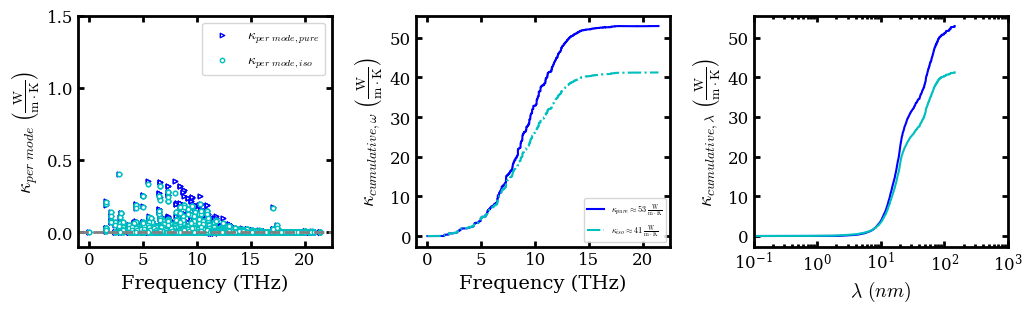

In [7]:
# Denote zeros to intake kappa tensor
kappa_tensor = np.zeros([mean_free_path.shape[0], 3, 3])
kappa_tensor_iso = np.zeros([mean_free_path.shape[0], 3, 3])

for i in range(3):
    for j in range(3):
        kappa_tensor[:, i, j] = np.loadtxt(data_folder +
    'ALD/15_15_15/inverse/300/quantum/conductivity_' +
    str(i) + '_' + str(j) + '.dat')
        kappa_tensor_iso[:, i, j] = np.loadtxt(data_folder +
    'ALD/15_15_15/inverse/300/quantum/isotopes/conductivity_' +
    str(i) + '_' + str(j) + '.dat')

# Sum over the 0th dimension to recover 3-by-3 kappa matrix
kappa_matrix = kappa_tensor.sum(axis=0)
print("Bulk thermal conductivity: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix)))
print("kappa matrix: ")
print(kappa_matrix)
print('\n')

kappa_matrix_iso = kappa_tensor_iso.sum(axis=0)
print("Bulk thermal conductivity with isotopic scattering: %.1f W m^-1 K^-1\n"
      %np.mean(np.diag(kappa_matrix_iso)))
print("kappa matrix with isotopic scattering: ")
print(kappa_matrix_iso)
print('\n')

# Compute kappa in per mode and cumulative representations
kappa_per_mode = kappa_tensor.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor)
lambda_sorted, kappa_cum_wrt_lambda = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor)

kappa_per_mode_iso = kappa_tensor_iso.sum(axis=-1).sum(axis=1)
freq_sorted, kappa_cum_wrt_freq_iso = cumulative_cond_cal(
    frequency.flatten(order='C'), kappa_tensor_iso)
lambda_sorted, kappa_cum_wrt_lambda_iso = cumulative_cond_cal(
    mean_free_path_norm, kappa_tensor_iso)

# Plot observables in subplot
figure(figsize=(12, 3))
subplot(1,3, 1)
set_fig_properties([gca()])
scatter(frequency.flatten(order='C'),
        kappa_per_mode, facecolor='w', edgecolor='b', s=10, marker='>', label='$\kappa_{per \ mode, pure }$')
scatter(frequency.flatten(order='C'),
        kappa_per_mode_iso, facecolor='w', edgecolor='c', s=10, marker='o', label='$\kappa_{per \ mode, iso }$')
gca().axhline(y = 0, color='0.5', ls='--', lw=2)
ylabel(r'$\kappa_{per \ mode}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=1, fontsize=10)
ylim([-0.1, 1.5])

subplot(1,3, 2)
set_fig_properties([gca()])
plot(freq_sorted, kappa_cum_wrt_freq, 'b',
     label=r'$\kappa_{pure} \approx 53 \;\frac{\rm{W}}{\rm{m}\cdot\rm{K}} $')
plot(freq_sorted, kappa_cum_wrt_freq_iso, c='c', 
     ls='-.', label=r"$\kappa_{iso} \approx 41 \;\frac{\rm{W}}{\rm{m}\cdot\rm{K}} $")
gca().set_yticks(np.arange(0, 60, 10))
ylabel(r'$\kappa_{cumulative, \omega}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xlabel('Frequency (THz)', fontsize=14)
legend(loc=4, fontsize=6)

subplot(1,3, 3)
set_fig_properties([gca()])
plot(lambda_sorted, kappa_cum_wrt_lambda, 'b')
plot(lambda_sorted, kappa_cum_wrt_lambda_iso, c='c')
gca().set_yticks(np.arange(0, 60, 10))
xlabel(r'$\lambda \ (nm)$', fontsize=14)
ylabel(r'$\kappa_{cumulative, \lambda}\;\left(\frac{\rm{W}}{\rm{m}\cdot\rm{K}}\right)$',fontsize=14)
xscale('log')
xlim([1e-1, 1e3])
subplots_adjust(wspace=0.33)
show()